## Introduction


**This notebook focuses on data preprocessing and quality assessment using the Sleep Health and Daily Performance dataset. The objective is to prepare the dataset for analysis by identifying data quality issues, handling missing values, detecting and treating outliers, and transforming numerical features through normalization techniques.Additionally, correlation analysis is performed to evaluate relationships between variables, followed by the application of Principal Component Analysis (PCA) when appropriate to reduce dimensionality and improve data interpretability.The overall goal is to ensure the dataset is clean, consistent, and suitable for further analysis and modeling.**


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## 1. Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv")

In [3]:
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## 2. Data Quality Assessment
### 2.1 Check Data Types 
- All types are correct

In [4]:
df.dtypes

person_id                        int64
age                              int64
gender                          object
occupation                      object
bmi                            float64
country                         object
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                      object
mental_health_condition         object
heart_rate_resting_bpm           int64
sleep_aid_used                   int64
shift_work                       int64
room_temperature_celsius 

## 3. Handling Missing Values
### 3.1 Detect Missing Values

In [5]:
df.isna()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isna().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

all values are zero, the dataset is complete. 

This dataset has no missing values, so I will introduce artificial ones for demonstration purposes.

In [7]:
df2 = df.copy()
df2.loc[0:5, 'gender'] = np.nan

In [8]:
df2.isna().sum()

person_id                      0
age                            0
gender                         6
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

Now the **gender** column contains missing values.

In [9]:
df2.head(10)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,NaN,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,NaN,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,NaN,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,NaN,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,NaN,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0
5,6,23,NaN,Driver,25.5,Brazil,8.16,5.7,17.3,20.1,...,71,1,0,22.7,0.70,Summer,Weekend,49.9,Mild,1
6,7,20,Female,Software Engineer,18.2,Netherlands,7.27,5.1,17.5,18.8,...,79,0,0,17.6,0.73,Spring,Weekend,57.9,Mild,1
7,8,48,Female,Freelancer,31.5,UK,8.04,6.5,25.3,22.3,...,60,1,0,21.6,0.47,Winter,Weekend,92.0,Mild,0
8,9,37,Male,Manager,29.9,USA,6.04,5.4,18.9,15.7,...,74,0,0,17.8,1.80,Autumn,Weekend,53.6,Mild,0
9,10,41,Female,Nurse,34.8,USA,6.22,4.9,21.4,15.5,...,80,1,0,24.4,1.51,Autumn,Weekday,67.8,Mild,1


I chose to drop the 6 rows with missing values because they represent a very small fraction of the total dataset. This approach maintains the integrity of the remaining data without introducing the potential bias of estimated (imputed) values.

In [10]:
df_remove = df2.dropna()

In [11]:
print('df with NaN: ',df2.shape)
print('df without NaN: ',df_remove.shape)

df with NaN:  (100000, 32)
df without NaN:  (99994, 32)


In [12]:
df_remove.isna().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

**The dataset now has fewer rows.**

## 4. Handling Outliers


In [13]:
import matplotlib.pyplot as plt

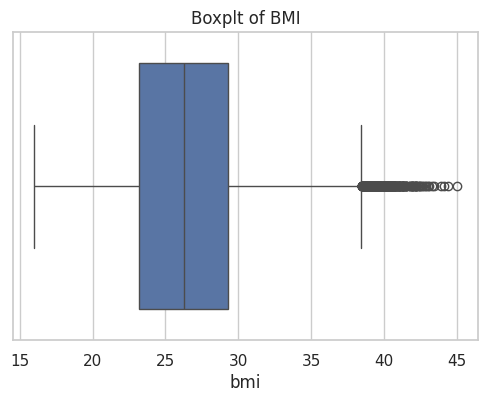

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['bmi'])

plt.title('Boxplt of BMI')
plt.show()

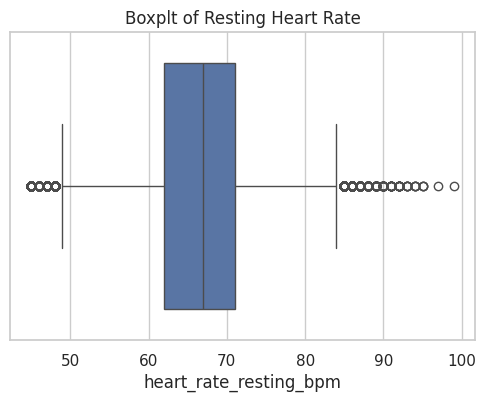

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['heart_rate_resting_bpm'])

plt.title('Boxplt of Resting Heart Rate')
plt.show()

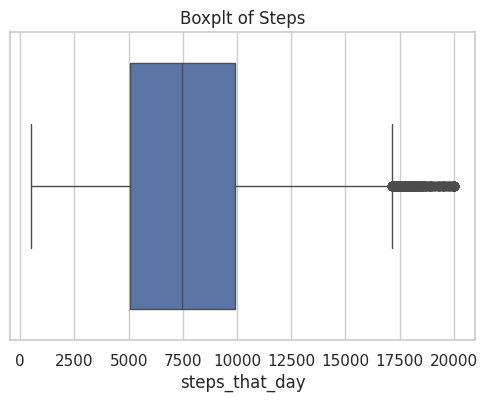

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['steps_that_day'])

plt.title('Boxplt of Steps')
plt.show()

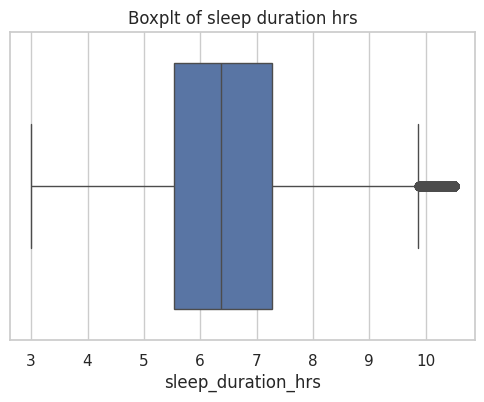

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['sleep_duration_hrs'])

plt.title('Boxplt of sleep duration hrs')
plt.show()

The IQR method was applied to key numerical features including BMI, resting heart rate, daily steps, and sleep duration to detect outliers. (Note: These features were selected as they are most sensitive to extreme variations and directly impact analysis quality.)
Values outside the whiskers represent potential outliers, which may distort statistical analysis and model performance. Therefore, appropriate handling will be  applied to ensure data quality and reliability.

In [18]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower) | (df['bmi'] > upper)]
outliers.head(15)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
189,190,25,Female,Nurse,40.2,Mexico,8.29,6.8,22.9,27.2,...,73,1,0,21.7,2.27,Autumn,Weekend,90.8,Healthy,1
247,248,58,Female,Student,39.6,India,5.59,5.3,24.3,17.9,...,64,0,0,21.1,2.70,Winter,Weekday,54.3,Mild,0
255,256,35,Female,Doctor,40.6,Brazil,6.76,5.1,17.7,17.2,...,64,0,0,19.7,0.42,Winter,Weekday,53.7,Healthy,0
364,365,54,Female,Doctor,41.8,Brazil,4.74,3.0,17.7,22.9,...,65,0,0,15.0,1.58,Autumn,Weekday,29.3,Severe,0
469,470,57,Female,Sales,38.6,Canada,6.29,3.1,19.7,13.4,...,75,1,0,15.8,1.42,Winter,Weekday,40.1,Moderate,0
507,508,46,Female,Software Engineer,38.9,Canada,6.33,4.4,21.2,14.4,...,60,1,0,20.8,0.52,Spring,Weekday,47.0,Healthy,0
884,885,44,Female,Sales,40.0,UK,4.72,5.6,19.0,14.7,...,69,1,0,18.8,0.63,Summer,Weekday,54.6,Mild,1
1155,1156,42,Male,Lawyer,38.8,France,7.36,6.5,22.8,19.2,...,65,1,0,18.7,0.00,Autumn,Weekend,75.6,Healthy,1
2173,2174,47,Female,Sales,39.4,India,4.20,5.8,23.5,22.3,...,72,0,0,21.7,2.12,Winter,Weekday,65.8,Mild,0
2397,2398,19,Female,Freelancer,41.4,Brazil,9.29,7.0,17.3,15.7,...,72,1,0,20.1,0.74,Summer,Weekend,67.8,Healthy,1


In [19]:
Q1 = df['heart_rate_resting_bpm'].quantile(0.25)
Q3 = df['heart_rate_resting_bpm'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['heart_rate_resting_bpm'] < lower) | (df['heart_rate_resting_bpm'] > upper)]
outliers.head(15)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
41,42,33,Male,Student,27.3,South Korea,5.34,3.1,12.1,12.8,...,86,1,0,20.9,1.86,Spring,Weekday,11.3,Severe,0
109,110,20,Female,Retired,23.9,South Korea,7.77,6.1,21.1,26.0,...,87,1,0,18.1,1.15,Summer,Weekday,83.1,Mild,1
120,121,45,Male,Manager,23.9,UK,8.65,6.9,18.9,20.2,...,45,1,0,19.9,1.48,Summer,Weekend,77.6,Healthy,0
424,425,20,Male,Sales,27.2,Australia,6.51,6.1,22.7,18.7,...,47,1,0,22.4,1.91,Autumn,Weekday,63.3,Healthy,1
443,444,29,Female,Teacher,21.7,Australia,9.82,4.7,16.2,18.6,...,86,1,0,20.1,2.46,Spring,Weekend,41.8,Mild,1
552,553,35,Male,Nurse,28.4,USA,3.73,4.1,24.7,21.3,...,87,0,0,18.8,0.81,Spring,Weekday,39.8,Mild,0
668,669,24,Male,Sales,30.3,India,7.44,5.8,21.7,18.1,...,85,0,0,22.7,1.47,Summer,Weekday,78.6,Healthy,1
840,841,18,Male,Lawyer,33.6,India,7.11,2.8,16.8,22.4,...,87,1,1,20.3,0.11,Winter,Weekday,37.9,Moderate,0
980,981,28,Female,Software Engineer,24.7,UK,5.51,4.8,16.9,24.1,...,47,1,0,21.8,1.63,Autumn,Weekday,46.1,Healthy,1
1097,1098,24,Female,Student,25.4,USA,4.68,4.7,23.5,19.3,...,47,1,0,26.0,0.18,Summer,Weekday,57.2,Healthy,0


In [20]:
Q1 = df['steps_that_day'].quantile(0.25)
Q3 = df['steps_that_day'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['steps_that_day'] < lower) | (df['steps_that_day'] > upper)]
outliers.head(15)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
237,238,18,Female,Software Engineer,24.0,UK,6.86,7.5,20.0,28.5,...,69,1,0,22.1,0.12,Summer,Weekend,100.0,Healthy,1
399,400,42,Male,Doctor,27.8,USA,6.80,4.0,17.5,19.6,...,58,1,0,17.1,1.88,Spring,Weekday,63.8,Healthy,1
1054,1055,68,Male,Nurse,32.4,Italy,4.86,4.0,22.4,10.8,...,62,1,0,15.8,2.39,Winter,Weekday,47.3,Moderate,0
1227,1228,26,Male,Retired,32.7,France,8.99,5.3,15.3,25.8,...,65,0,0,20.0,0.78,Spring,Weekend,47.8,Mild,1
1417,1418,22,Male,Lawyer,28.1,Canada,5.60,4.3,26.1,25.8,...,62,0,0,24.4,1.85,Winter,Weekday,54.1,Healthy,0
1640,1641,35,Male,Sales,25.0,Brazil,9.15,7.6,21.3,22.1,...,58,1,0,16.6,0.37,Spring,Weekend,91.1,Healthy,0
1657,1658,27,Male,Lawyer,27.8,Brazil,4.08,1.8,10.0,18.4,...,64,0,0,24.7,1.54,Autumn,Weekday,0.4,Severe,1
1768,1769,29,Male,Doctor,27.7,India,4.68,3.7,22.8,27.8,...,55,0,0,27.1,1.84,Spring,Weekday,40.7,Moderate,0
1821,1822,22,Female,Software Engineer,24.2,Brazil,4.68,4.2,25.3,30.0,...,59,0,1,21.7,0.58,Winter,Weekday,61.5,Mild,0
2676,2677,29,Male,Freelancer,22.3,Italy,7.16,5.5,23.6,23.9,...,61,1,0,17.0,1.15,Summer,Weekday,77.3,Healthy,0


In [21]:
Q1 = df['sleep_duration_hrs'].quantile(0.25)
Q3 = df['sleep_duration_hrs'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['sleep_duration_hrs'] < lower) | (df['sleep_duration_hrs'] > upper)]
outliers.head(15)

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
26,27,24,Male,Retired,27.2,Japan,9.98,7.3,19.7,24.2,...,72,0,0,16.1,0.23,Summer,Weekend,80.7,Healthy,1
178,179,54,Male,Freelancer,23.1,Japan,10.02,7.1,21.5,13.2,...,70,1,0,20.0,1.95,Autumn,Weekend,81.7,Healthy,1
185,186,39,Female,Freelancer,27.1,Canada,10.50,4.0,22.7,19.4,...,64,1,0,19.5,0.79,Summer,Weekend,43.6,Severe,1
573,574,37,Male,Retired,26.7,India,10.10,5.2,22.4,22.6,...,54,0,0,18.9,0.03,Spring,Weekday,62.6,Mild,1
925,926,18,Male,Teacher,28.8,Netherlands,9.96,5.7,18.2,24.7,...,69,0,0,20.4,2.06,Winter,Weekend,47.0,Mild,0
1104,1105,66,Female,Teacher,33.7,UK,10.10,5.7,16.8,14.5,...,65,1,0,21.0,0.46,Summer,Weekend,52.1,Moderate,1
1224,1225,31,Female,Retired,20.1,USA,10.48,6.8,14.1,19.1,...,68,0,0,17.6,1.18,Winter,Weekend,61.3,Healthy,1
1278,1279,23,Male,Retired,26.4,Italy,9.98,7.2,20.5,19.8,...,75,1,0,21.5,1.08,Summer,Weekend,79.8,Healthy,1
1416,1417,19,Female,Retired,23.8,UK,10.25,7.1,22.3,30.0,...,57,1,0,23.1,2.28,Summer,Weekend,86.7,Healthy,1
1442,1443,39,Female,Homemaker,30.2,Brazil,10.50,3.8,16.2,20.6,...,61,1,0,28.0,0.14,Spring,Weekend,34.2,Moderate,1


In [22]:
cols = [
    'bmi',
    'heart_rate_resting_bpm',
    'steps_that_day',
    'sleep_duration_hrs'
]
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"{col}: Lower={lower}, Upper={upper}")

bmi: Lower=14.049999999999997, Upper=38.45
heart_rate_resting_bpm: Lower=48.5, Upper=84.5
steps_that_day: Lower=-2218.0, Upper=17150.0
sleep_duration_hrs: Lower=2.9200000000000013, Upper=9.879999999999999


In [23]:

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

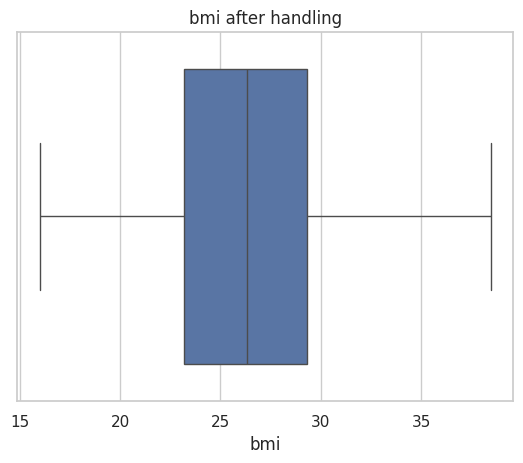

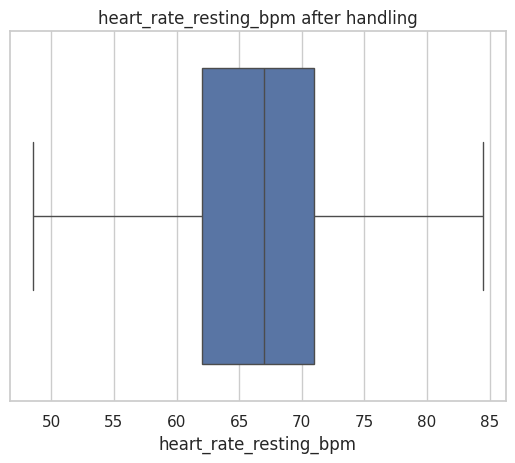

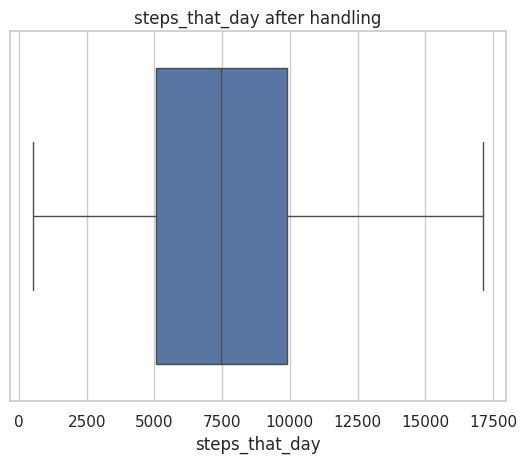

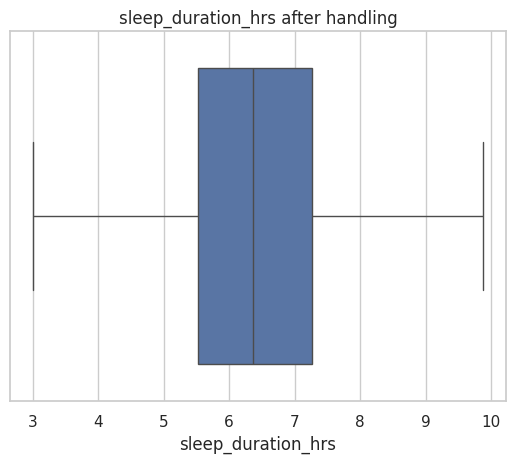

In [24]:
for col in cols:
    sns.boxplot(x=df[col])
    plt.title(f'{col} after handling')
    plt.show()

Outliers were handled using the IQR method by capping extreme values within the calculated bounds. This reduces distortion while preserving the dataset.

## 5. Data Transformation – Normalization


In [25]:
norm_cols = [
    'age',
    'bmi',
    'sleep_duration_hrs',
    'sleep_quality_score',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'caffeine_mg_before_bed',
    'alcohol_units_before_bed',
    'screen_time_before_bed_mins',
    'steps_that_day',
    'nap_duration_mins',
    'stress_score',
    'work_hours_that_day',
    'heart_rate_resting_bpm',
    'room_temperature_celsius',
    'weekend_sleep_diff_hrs',
    'cognitive_performance_score'
]

In [26]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[norm_cols] = minmax_scaler.fit_transform(df[norm_cols])

In [27]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[norm_cols] = zscore_scaler.fit_transform(df[norm_cols])

In [28]:
df_minmax[norm_cols].head()
df_zscore[norm_cols].head()

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score
0,-0.517099,-0.131000,-0.182886,1.147590,0.661334,-0.224267,-0.505888,-0.559828,-0.563468,-0.707956,-0.261334,-0.698392,-0.823429,1.023854,-0.498797,-0.151194,0.812757,0.636988
1,1.838759,-0.959567,1.495363,1.346726,1.951151,-1.259299,-0.374037,-0.559828,-0.563468,-0.685509,0.757925,-0.324341,-1.070467,-1.186972,-2.037205,-0.875944,-1.360982,1.805551
2,0.660830,-0.287756,-2.113267,-2.569611,-0.012889,-0.953494,0.812624,-0.559828,1.324829,0.571498,0.500431,0.610786,1.276391,-1.014700,0.759900,-0.910456,0.596655,-2.549592
3,0.207780,0.719960,0.289860,1.014833,-0.745739,-0.600642,-0.901442,-0.559828,0.380681,-0.259025,0.491162,1.171862,-0.514632,-0.124627,0.620045,-0.496313,1.486489,0.385298
4,-1.060759,-0.601268,-1.104742,-1.109282,0.895846,-0.459501,1.340029,0.016579,-0.563468,0.189906,-0.933019,-0.698392,1.029354,0.937718,0.620045,-0.289242,0.075466,-0.949560


Continuous numerical features were normalized using both Min-Max scaling and Z-score standardization.
Categorical, binary, and identifier variables were excluded as normalization is not applicable to these data types.
This ensures that features are on a comparable scale and improves the reliability of further analysis.

In [29]:
df_zscore[norm_cols].mean()


age                           -1.978506e-16
bmi                            6.224354e-17
sleep_duration_hrs            -6.912870e-16
sleep_quality_score           -9.627854e-17
rem_percentage                 3.386447e-16
deep_sleep_percentage          3.871037e-16
sleep_latency_mins             1.222134e-17
caffeine_mg_before_bed         4.760636e-18
alcohol_units_before_bed      -1.705303e-18
screen_time_before_bed_mins    1.183054e-17
steps_that_day                 7.972289e-17
nap_duration_mins             -6.394885e-18
stress_score                  -2.590639e-16
work_hours_that_day           -1.779199e-16
heart_rate_resting_bpm         1.813305e-16
room_temperature_celsius       1.254321e-15
weekend_sleep_diff_hrs         1.062261e-16
cognitive_performance_score    8.853362e-17
dtype: float64

The mean values of all normalized features are approximately zero, confirming that Z-score standardization was applied correctly.
Minor deviations from zero are due to floating-point precision and are negligible.

In [30]:
df_zscore[norm_cols].std()

age                            1.000005
bmi                            1.000005
sleep_duration_hrs             1.000005
sleep_quality_score            1.000005
rem_percentage                 1.000005
deep_sleep_percentage          1.000005
sleep_latency_mins             1.000005
caffeine_mg_before_bed         1.000005
alcohol_units_before_bed       1.000005
screen_time_before_bed_mins    1.000005
steps_that_day                 1.000005
nap_duration_mins              1.000005
stress_score                   1.000005
work_hours_that_day            1.000005
heart_rate_resting_bpm         1.000005
room_temperature_celsius       1.000005
weekend_sleep_diff_hrs         1.000005
cognitive_performance_score    1.000005
dtype: float64

The standard deviation of all normalized features is approximately 1, confirming that Z-score standardization was correctly applied.
Minor deviations are due to floating-point precision and are negligible.

## Checking Correlation Before Applying PCA


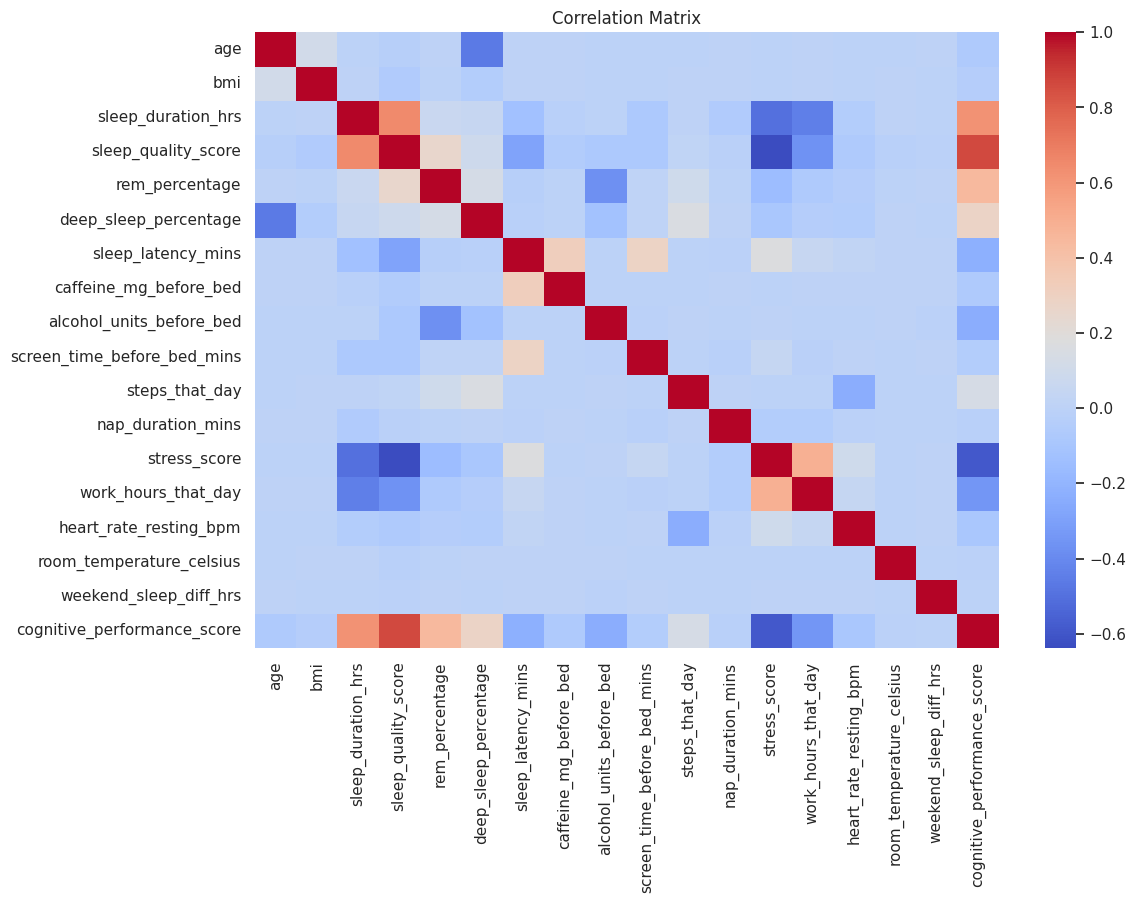

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[norm_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The heatmap shows clear patterns of correlation among multiple features, indicating that the dataset contains interdependent variables. Therefore, PCA is applied to reduce dimensionality and eliminate redundancy.

## 6. Data Reduction – Principal Component Analysis (PCA)

In [32]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_zscore[norm_cols])

PCA()

In [33]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.19432025, 0.08946514, 0.07722279, 0.07380402, 0.06764436,
       0.05699956, 0.05571803, 0.05564914, 0.05540004, 0.05415338,
       0.04311135, 0.03890727, 0.03386606, 0.0314188 , 0.02771806,
       0.02413744, 0.01566421, 0.00480009])

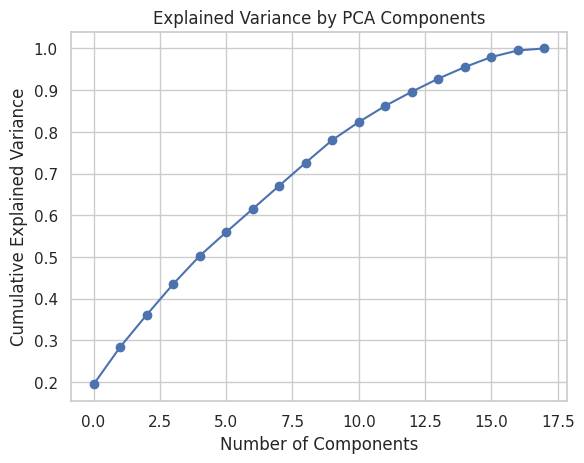

In [34]:
import matplotlib.pyplot as plt

plt.plot(explained_variance.cumsum(), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.show()


In [35]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
principal_components = pca.fit_transform(df_zscore[norm_cols])

df_pca = pd.DataFrame(principal_components, 
                      columns=[f'PC{i+1}' for i in range(10)])

Based on the cumulative explained variance plot, 10 principal components were selected as they capture approximately 80% of the total variance.
This reduces dimensionality while retaining most of the important information in the dataset.